# Refresh Semantisch model via Semantic link

## Handleiding
Dit notebook ververst het semantisch model -- Datamodel Isero-Polvo --. Dit wordt gedaan Via semantic link. De manier van verversen kan op verschillende wijzen worden gedaan. Deze twee manier kunnen beide in 1 verversing worden gebruikt. 

### 0. Aanmaken van een tabel in de lakehouse


```
df_klaar = pd.DataFrame([{
    'request_id': '', 
    'status': '', 
    'tabel': '', 
    'partitie': '',
    'timestamp': datetime.now(ZoneInfo("Europe/Amsterdam")).strftime('%Y-%m-%d %H:%M:%S'),
    'WorkspaceId': WorkspaceId,
    'objects': ''
}])

logs_df = spark.createDataFrame(df_klaar)

logs_df.write.mode("append").option("mergeSchema", "true").format("delta").saveAsTable("Bronze.refresh_logs")
```

### 1. Serieel verversen 

Deze manier van verversen ververst alle partities afzonderlijk van elkaar in Serie. Voordeel van deze manier is dit goed gebruikt kan worden in situaties waarin er weinig memory beschikbaar is. Daarnaast als de verversmodus Transactioneel is, is de impact van foute verversingen klein. Als er 1 partitie faalt, faalt echt alleen deze partitie en wordt de rest goed ververst.



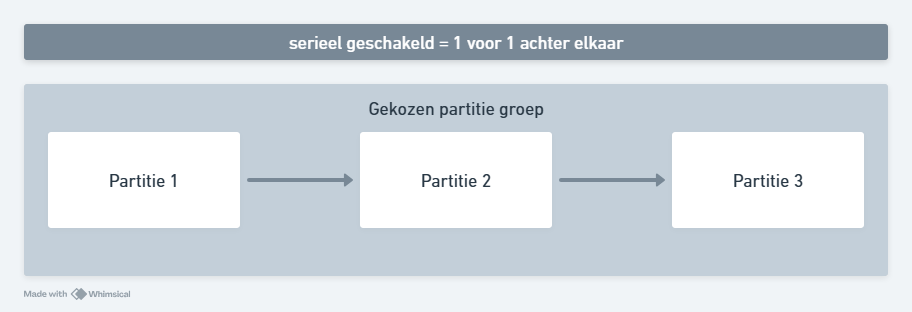

Als je serieel wilt verversen dan begin je met het zetten van een filter op je invoer dataframe. Kopier de volgende code naar een code cell (doe dit onder het laatste kopje: verversen van het model)

```
Welke partitie groep wil je hier gebruiken? vul deze in. Zorg er voor dat je gekozen partitie groep onder -- invoer variabelen -- is gedefinierd. 
partieGroep_filter = "cy" # kies hier voor de partitie groep die je wilt gebruiken
```

Gebruik vervolgens de volgende functie om de functie af te vuren:

```
afknijpen van hoeveelheid tabellen / partities
tables = tables[tables['partitieGroep'] == partieGroep_filter ]
tables_spark = spark.createDataFrame(tables)
display(tables_spark)

functie aanroepen om de tabellen te refreshen
refresh_pbi_model(tables)
```

Herhaal dit voor zovaak als je wilt.



### 2. Parallel per partitie groep
 Deze manier is goed te gebruiken wanneer er voldoende memory beschikbaar is maar je graag je partities wilt op delen in groepen. Deze groepen kan je zelf definieren onder -- Invoer variabelen --. De partities binnen een partitie groep worden volledig parralel ververst rekening houden met de ingestelde MaxParralelism. De partitie groepen worden serieel van elkaar ververst. De volgorde hiervan kan je bepalen onder de invoer variabelen. 

 vul als aller eerste de invoer variabele partitieGroups_to_refresh. Dit is een array die gevuld kan worden met de groepen die je wilt verversen. Deze array vul je als volgt in:

["naam van de groep", "naam van de groep 2", "naam van de groep 3"]

De volgorde van de array wordt aangehouden. De eerste groep in de array wordt als eerste ververst en de laatste als laatste.


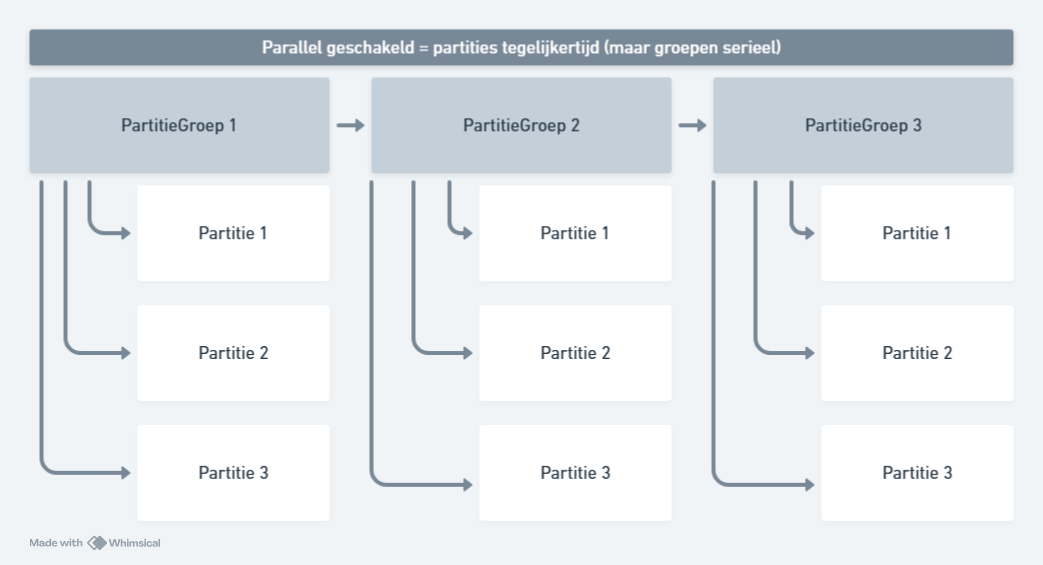

Het parallel verversen werkt in 2 stappen:
- vul de array in
- voer de functie uit (kopier hier voor de onderstaande functie)

```
#functie aanroepen om de tabellen te refreshen
refresh_pbi_model_2(partitieGroups_to_refresh, tables)
```

## logging instellen
alle verversingen worden gelogd. Dit wordt weg geschreven in een lakehouse naar keuze. Het kiezen van het lakehouse kan onder -- Invoer variabelen --

Einde handleiding

.---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------.

## Invoer variabelen

In [1]:
"""
Verplicht in te voeren invoer variabelen
"""

#worksapce id
WorkspaceId = spark.conf.get("trident.workspace.id")

#model definieren
model = "Datamodel Isero-Polvo"

#voor het wegschrijven van de logs|
tablePath = "Bronze.refresh_logs"

# Hier worden de partitie groepen gedefinierd. verander de naam tussen de haakjes om daarop te zoeken en deze naam te geven.
def partitieGroep(partitie):
    if 'cy' in partitie:        # er wordt gezocht of 'cy' voorkomt in de partitie naam (denk aan verkopen_cy).
        return 'cy'             # gebruik 'cy' als partitieGroep naam.
    elif 'py' in partitie:  
        return 'py'
    elif '2yago' in partitie:
        return '2yago'
    elif '3yago' in partitie:
        return '3yago'
    elif '4yago' in partitie:
        return '4yago'
    else:
        return 'full'


"""
parralel refresh.
"""

# Te verversen partitie groepen. 
# Volgorde wordt van boven naar beneden uitgevoerd. 
partitieGroups_to_refresh = ["cy", "full", "py"]
#partitieGroups_to_refresh = ["full"]

max_parallelism = 10
refresh_type = "full"
retry_count = 0
commit_mode = "transactional"


print(WorkspaceId)

StatementMeta(, 70e68969-8512-4f17-9db4-5fd7fc63d012, 3, Finished, Available, Finished, False)

82a27db2-9072-4cd3-9287-07c4a075371d


## libaries en Functies

Gebruik de notebook libaries en functies om de libaries en functies in te laden

In [2]:
%run Refresh via semantic-link 2.0: libaries en functies

StatementMeta(, 70e68969-8512-4f17-9db4-5fd7fc63d012, 5, Finished, Available, Finished, True)

## Tabellen / partities dataframe samenstellen
alle bestaande partities in het model worden opgehaald. Hier wordt een dataframe van gemaakt. 

In [3]:
#alle partities weergeven en partitie groep aanmaken -> dit klaar zetten als df -> tables
tables = fabric.list_partitions(dataset= model, workspace= WorkspaceId)
tables = tables.sort_values("Partition Name")
tables['partitieGroep'] = tables['Partition Name'].apply(partitieGroep)

StatementMeta(, 70e68969-8512-4f17-9db4-5fd7fc63d012, 6, Finished, Available, Finished, False)

## Verversen van model
Plaats hieronder je code

In [4]:
#functie aanroepen om de tabellen te refreshen
refresh_pbi_model_2(partitieGroups_to_refresh, tables)

StatementMeta(, 70e68969-8512-4f17-9db4-5fd7fc63d012, 7, Submitted, Running, Running, True)

## Fall back

In [ ]:
notebookutils.notebook.run(
    path="refresh via semantic link 2.0 [Fall back]",
    timeout_seconds= 14400                              # 4 uur
    )

StatementMeta(, , -1, Waiting, , Waiting, True)